# Data Loading

In [48]:
import pandas as pd
import numpy as np
import ast
import re

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from collections import Counter
from itertools import combinations

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
import shap

from IPython.display import display

In [2]:
# Main international job postings dataset
jobs = pd.read_csv("data_jobs.csv")

# Philippine local dataset (reserved for later external validation)
lfs = pd.read_csv("FIES2015 - LFSJAN16 CSV - Cleaned.csv", low_memory=False)

# World Bank country-level context data
econ = pd.read_csv("world_bank_data_2025.csv")

print("jobs shape:", jobs.shape)
print("lfs shape:", lfs.shape)
print("econ shape:", econ.shape)

display(jobs.head())

jobs shape: (785741, 17)
lfs shape: (207212, 154)
econ shape: (3472, 16)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


# Data Preprocessing

In [3]:
# -------------------------
# COUNTRY STANDARDIZATION
# -------------------------
country_map = {
    "Russia": "Russian Federation",
    "Vietnam": "Viet Nam",
    "South Korea": "Korea, Rep.",
    "North Korea": "Korea, Dem. People's Rep.",
    "Egypt": "Egypt, Arab Rep.",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Iran": "Iran, Islamic Rep.",
    "Venezuela": "Venezuela, RB",
    "Slovakia": "Slovak Republic",
    "Hong Kong": "Hong Kong SAR, China",
    "Macedonia (FYROM)": "North Macedonia",
    "Palestine": "West Bank and Gaza",
    "Laos": "Lao PDR",
    "Syria": "Syrian Arab Republic",
    "Turkey": "Turkiye",
    "Yemen": "Yemen, Rep.",
    "United States Virgin Islands": "Virgin Islands (U.S.)",
    "Bahamas": "Bahamas, The",
    "Brunei": "Brunei Darussalam",
    "Congo, Democratic Republic of the": "Congo, Dem. Rep.",
    "Curaçao": "Curacao",
    "Gambia": "Gambia, The",
    "Kyrgyzstan": "Kyrgyz Republic",
    "Taiwan": "Taiwan, China",
    "U.S. Virgin Islands": "Virgin Islands (U.S.)"
}

In [4]:
# -------------------------
# WORLD BANK 2023 FEATURES
# -------------------------
econ_2023 = econ[econ["year"] == 2023].copy()

econ_2023 = econ_2023[[
    "country_name",
    "GDP per Capita (Current USD)",
    "GDP (Current USD)",
    "Unemployment Rate (%)",
    "Inflation (CPI %)",
    "GDP Growth (% Annual)"
]]

# interest rate, gross national income (USD)

econ_2023.columns = [
    "country",
    "gdp_per_capita",
    "gdp",
    "unemployment",
    "inflation",
    "gdp_growth"
]

display(econ_2023.head())

,country,gdp_per_capita,gdp,unemployment,inflation,gdp_growth
13,Aruba,33984.790620,3.648573e+09,NaN,NaN,4.263719
29,Afghanistan,415.707417,1.723305e+10,13.991,-4.644709,2.710887
45,Angola,2308.159767,8.482465e+10,14.537,13.644102,1.001289
61,Albania,8575.171134,2.354718e+10,10.108,4.759764,3.936625
77,Andorra,46812.448449,3.785067e+09,NaN,NaN,2.583555


In [5]:
# -------------------------
# KEEP USEFUL COLUMNS
# -------------------------
wanted_cols = [
    "job_title_short",
    "job_title",
    "job_location",
    "job_via",
    "job_schedule_type",
    "job_work_from_home",
    "job_no_degree_mention",
    "job_health_insurance",
    "job_country",
    "salary_rate",
    "salary_year_avg",
    "salary_hour_avg",
    "company_name",
    "job_skills",
    "job_type_skills"
]

existing_cols = [c for c in wanted_cols if c in jobs.columns]

jobs_model = jobs[existing_cols].copy()

# standardize country names
jobs_model["job_country"] = jobs_model["job_country"].replace(country_map)

# filter to North America
jobs_model = jobs_model[jobs_model["job_country"].isin([
    "United States", "Canada"
])].copy()

print("Shape after NA filter:", jobs_model.shape)

# merge economic features
jobs_model = jobs_model.merge(
    econ_2023,
    left_on="job_country",
    right_on="country",
    how="left"
)

# fill numeric macroeconomic missings with median
for col in ["gdp_per_capita", "gdp", "unemployment", "inflation", "gdp_growth"]:
    if col in jobs_model.columns:
        jobs_model[col] = jobs_model[col].fillna(jobs_model[col].median())

print("jobs_model shape after merge:", jobs_model.shape)
display(jobs_model.head())

Shape after NA filter: (222321, 15)
jobs_model shape after merge: (222321, 21)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,salary_hour_avg,company_name,job_skills,job_type_skills,country,gdp_per_capita,gdp,unemployment,inflation,gdp_growth
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,False,False,United States,NaN,...,NaN,Boehringer Ingelheim,NaN,NaN,United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
1,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,True,False,United States,NaN,...,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
2,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,False,False,United States,NaN,...,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '...",United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
3,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,False,False,United States,NaN,...,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['...",United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
4,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,False,False,United States,NaN,...,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'...",United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556


In [6]:
print(jobs_model["job_country"].value_counts())

job_country
United States    206292
Canada            16029
Name: count, dtype: int64


In [7]:
# -------------------------
# TARGET SALARY
# -------------------------
def get_salary(row):
    if pd.notna(row.get("salary_year_avg")):
        return row["salary_year_avg"]
    if pd.notna(row.get("salary_hour_avg")):
        return row["salary_hour_avg"] * 40 * 52
    return np.nan

jobs_model["salary"] = jobs_model.apply(get_salary, axis=1)
jobs_model = jobs_model.dropna(subset=["salary"]).copy()

print("Shape after removing missing salaries:", jobs_model.shape)

Shape after removing missing salaries: (25685, 22)


In [8]:
# remove salary outliers (IQR)
Q1 = jobs_model["salary"].quantile(0.25)
Q3 = jobs_model["salary"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

jobs_model = jobs_model[
    (jobs_model["salary"] >= lower) &
    (jobs_model["salary"] <= upper)
].copy()

jobs_model["salary_log"] = np.log1p(jobs_model["salary"])

print("Shape after outlier removal:", jobs_model.shape)
print("Salary summary:")
display(jobs_model["salary"].describe())

Shape after outlier removal: (25176, 23)
Salary summary:


count     25176.000000
mean     112131.955287
std       42085.044017
min       16640.000000
25%       82500.000000
50%      110219.203491
75%      140000.000000
max      231000.000000
Name: salary, dtype: float64

In [9]:
# -------------------------
# ADD ENGINEERED ECON FEATURES
# -------------------------
jobs_model["gdp_per_capita_log"] = np.log1p(jobs_model["gdp_per_capita"])
jobs_model["gdp_log"] = np.log1p(jobs_model["gdp"])
jobs_model["labor_market_tightness"] = 1 - jobs_model["unemployment"]
jobs_model["real_gdp_per_capita"] = jobs_model["gdp_per_capita"] / (1 + jobs_model["inflation"] / 100)

In [10]:
# -------------------------
# CLEAN SKILLS
# -------------------------
def clean_skills(x):
    if isinstance(x, list):
        all_items = []
        for item in x:
            text = str(item).strip().strip("'\"[]")
            parts = re.split(r",\s*", text)
            all_items.extend(parts)
        return [s.strip().strip("'\" ").lower() for s in all_items if s.strip()]
    
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return clean_skills(parsed)
        except:
            pass
        x_clean = x.strip().strip("[]")
        parts = re.split(r",\s*", x_clean)
        return [s.strip().strip("'\" ").lower() for s in parts if s.strip()]
    
    return []

jobs_model["skills_list"] = jobs_model["job_skills"].apply(clean_skills)
jobs_model["skills_list"] = jobs_model["skills_list"].apply(lambda x: list(dict.fromkeys(x)))
jobs_model["skill_count"] = jobs_model["skills_list"].apply(len)

display(jobs_model[["job_skills", "skills_list", "skill_count"]].head(10))

,job_skills,skills_list,skill_count
18,"['sql', 'sql server']","[sql, sql server]",2
20,"['python', 'java', 'aws', 'databricks', 'spark']","[python, java, aws, databricks, spark]",5
34,"['sql', 'python']","[sql, python]",2
39,"['sql', 'r', 'python', 'express']","[sql, r, python, express]",4
40,"['python', 'r', 'alteryx', 'tableau']","[python, r, alteryx, tableau]",4
45,"['r', 'python', 'sql', 't-sql', 'hadoop', 'spa...","[r, python, sql, t-sql, hadoop, spark, tableau]",7
61,"['golang', 'scala', 'python', 'java', 'hadoop'...","[golang, scala, python, java, hadoop, spark]",6
73,"['excel', 'powerpoint']","[excel, powerpoint]",2
101,"['sql', 'python', 'java', 'mysql', 'postgresql...","[sql, python, java, mysql, postgresql, aws, gc...",8
102,"['r', 'electron']","[r, electron]",2


In [11]:
# -------------------------
# PARSE job_type_skills
# -------------------------
def parse_skill_dict(x):
    if isinstance(x, dict):
        return x
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return {}
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            return parsed if isinstance(parsed, dict) else {}
        except:
            return {}
    return {}

jobs_model["job_type_skills_parsed"] = jobs_model["job_type_skills"].apply(parse_skill_dict)

skill_type_categories = [
    "analyst_tools", "cloud", "libraries", "databases", "programming",
    "other", "webframeworks", "os", "async", "sync"
]

for cat in skill_type_categories:
    jobs_model[f"{cat}_count"] = jobs_model["job_type_skills_parsed"].apply(
        lambda d: len(d.get(cat, [])) if isinstance(d, dict) else 0
    )

jobs_model["num_skill_categories"] = jobs_model["job_type_skills_parsed"].apply(
    lambda d: len([k for k, v in d.items() if isinstance(v, list) and len(v) > 0]) if isinstance(d, dict) else 0
)

display(
    jobs_model[
        ["job_type_skills", "job_type_skills_parsed"] +
        [f"{cat}_count" for cat in skill_type_categories] +
        ["num_skill_categories"]
    ].head(10)
)

,job_type_skills,job_type_skills_parsed,analyst_tools_count,cloud_count,libraries_count,databases_count,programming_count,other_count,webframeworks_count,os_count,async_count,sync_count,num_skill_categories
18,"{'databases': ['sql server'], 'programming': [...","{'databases': ['sql server'], 'programming': [...",0,0,0,1,1,0,0,0,0,0,2
20,"{'cloud': ['aws', 'databricks'], 'libraries': ...","{'cloud': ['aws', 'databricks'], 'libraries': ...",0,2,1,0,2,0,0,0,0,0,3
34,"{'programming': ['sql', 'python']}","{'programming': ['sql', 'python']}",0,0,0,0,2,0,0,0,0,0,1
39,"{'programming': ['sql', 'r', 'python'], 'webfr...","{'programming': ['sql', 'r', 'python'], 'webfr...",0,0,0,0,3,0,1,0,0,0,2
40,"{'analyst_tools': ['alteryx', 'tableau'], 'pro...","{'analyst_tools': ['alteryx', 'tableau'], 'pro...",2,0,0,0,2,0,0,0,0,0,2
45,"{'analyst_tools': ['tableau'], 'libraries': ['...","{'analyst_tools': ['tableau'], 'libraries': ['...",1,0,2,0,4,0,0,0,0,0,3
61,"{'libraries': ['hadoop', 'spark'], 'programmin...","{'libraries': ['hadoop', 'spark'], 'programmin...",0,0,2,0,4,0,0,0,0,0,2
73,"{'analyst_tools': ['excel', 'powerpoint']}","{'analyst_tools': ['excel', 'powerpoint']}",2,0,0,0,0,0,0,0,0,0,1
101,"{'cloud': ['aws', 'gcp'], 'databases': ['mysql...","{'cloud': ['aws', 'gcp'], 'databases': ['mysql...",0,2,1,2,3,0,0,0,0,0,4
102,"{'libraries': ['electron'], 'programming': ['r']}","{'libraries': ['electron'], 'programming': ['r']}",0,0,1,0,1,0,0,0,0,0,2


In [12]:
# -------------------------
# REGION GROUPING
# -------------------------
region_map = {
    "United States": "NA", "Canada": "NA",
    "Mexico": "LATAM", "Costa Rica": "LATAM", "Guatemala": "LATAM", "Panama": "LATAM",
    "Brazil": "LATAM", "Argentina": "LATAM", "Chile": "LATAM", "Peru": "LATAM",
    "United Kingdom": "EU", "Germany": "EU", "France": "EU", "Spain": "EU", "Italy": "EU",
    "Belgium": "EU", "Denmark": "EU", "Poland": "EU", "Portugal": "EU", "Sweden": "EU",
    "Netherlands": "EU", "Ireland": "EU", "Austria": "EU", "Romania": "EU", "Finland": "EU",
    "Switzerland": "EU", "Norway": "EU",
    "Philippines": "SEA", "Singapore": "SEA", "Indonesia": "SEA", "Malaysia": "SEA",
    "Thailand": "SEA", "Viet Nam": "SEA", "Brunei Darussalam": "SEA",
    "Japan": "EAST_ASIA", "Korea, Rep.": "EAST_ASIA", "Taiwan, China": "EAST_ASIA", "China": "EAST_ASIA",
    "India": "SOUTH_ASIA", "Pakistan": "SOUTH_ASIA", "Bangladesh": "SOUTH_ASIA",
    "United Arab Emirates": "ME", "Israel": "ME", "Jordan": "ME", "Turkiye": "ME",
    "South Africa": "AFRICA", "Nigeria": "AFRICA", "Kenya": "AFRICA", "Morocco": "AFRICA", "Egypt, Arab Rep.": "AFRICA",
    "Australia": "OCEANIA", "New Zealand": "OCEANIA"
}

jobs_model["region"] = jobs_model["job_country"].map(region_map).fillna("OTHER")

In [13]:
# -------------------------
# FILTER RARE TITLES
# -------------------------
title_counts = jobs_model["job_title_short"].value_counts()
common_titles = title_counts[title_counts >= 100].index

jobs_model = jobs_model[jobs_model["job_title_short"].isin(common_titles)].copy()

print("Final modeling dataframe shape:", jobs_model.shape)
display(jobs_model.head())

Final modeling dataframe shape: (25134, 42)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,libraries_count,databases_count,programming_count,other_count,webframeworks_count,os_count,async_count,sync_count,num_skill_categories,region
18,Senior Data Engineer,Sr SQL Database Engineer with Data Warehouse /...,NaN,via LinkedIn,Contractor,False,True,False,United States,hour,...,0,1,1,0,0,0,0,0,2,NA
20,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Contractor,True,False,False,United States,hour,...,1,0,2,0,0,0,0,0,3,NA
34,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,False,True,United States,year,...,0,0,2,0,0,0,0,0,1,NA
39,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,False,True,United States,year,...,0,0,3,0,1,0,0,0,2,NA
40,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,False,True,United States,year,...,0,0,2,0,0,0,0,0,2,NA


# Add Feature Engineering after EDA

In [14]:
# -------------------------
# ADD COUNTRY GROUPING
# -------------------------
top_countries_global = jobs_model["job_country"].value_counts().head(20).index.tolist()

jobs_model["country_grouped"] = jobs_model["job_country"].where(
    jobs_model["job_country"].isin(top_countries_global),
    "OTHER"
)

# -------------------------
# TITLE FEATURES
# -------------------------
jobs_model["job_title_clean"] = jobs_model["job_title"].fillna("").astype(str).str.lower()

jobs_model["is_senior"] = jobs_model["job_title_clean"].str.contains(r"\bsenior\b", regex=True).astype(int)
jobs_model["is_lead"] = jobs_model["job_title_clean"].str.contains(r"\blead\b", regex=True).astype(int)
jobs_model["is_principal"] = jobs_model["job_title_clean"].str.contains(r"\bprincipal\b", regex=True).astype(int)
jobs_model["is_manager"] = jobs_model["job_title_clean"].str.contains(r"\bmanager\b", regex=True).astype(int)
jobs_model["is_junior"] = jobs_model["job_title_clean"].str.contains(r"\bjunior\b", regex=True).astype(int)
jobs_model["is_intern"] = jobs_model["job_title_clean"].str.contains(r"\bintern\b", regex=True).astype(int)

jobs_model["title_length"] = jobs_model["job_title"].fillna("").astype(str).apply(len)
jobs_model["title_word_count"] = jobs_model["job_title"].fillna("").astype(str).apply(lambda x: len(x.split()))

# -------------------------
# STACK FEATURES FROM skills_list
# -------------------------
jobs_model["cloud_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["aws", "azure", "gcp", "databricks"])
)

jobs_model["visualization_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["tableau", "power bi", "looker", "qlik"])
)

jobs_model["ml_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["tensorflow", "pytorch", "scikit-learn", "keras"])
)

jobs_model["big_data_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["spark", "hadoop", "kafka", "airflow"])
)

jobs_model["core_data_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["sql", "python", "r", "excel"])
)

# -------------------------
# FEATURE INTERACTIONS
# -------------------------

jobs_model["senior_x_ml"] = jobs_model["is_senior"] * jobs_model["ml_stack"]
jobs_model["cloud_x_gdp"] = jobs_model["cloud_stack"] * jobs_model["gdp_per_capita_log"]
jobs_model["data_stack_total"] = (
    jobs_model["cloud_stack"] +
    jobs_model["ml_stack"] +
    jobs_model["big_data_stack"]
)

print("Shape after additional feature engineering:", jobs_model.shape)
display(jobs_model.head())

Shape after additional feature engineering: (25134, 60)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,title_length,title_word_count,cloud_stack,visualization_stack,ml_stack,big_data_stack,core_data_stack,senior_x_ml,cloud_x_gdp,data_stack_total
18,Senior Data Engineer,Sr SQL Database Engineer with Data Warehouse /...,NaN,via LinkedIn,Contractor,False,True,False,United States,hour,...,60,10,0,0,0,0,1,0,0.000000,0
20,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Contractor,True,False,False,United States,hour,...,20,3,2,0,0,1,1,0,22.647652,3
34,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,False,True,United States,year,...,39,8,0,0,0,0,2,0,0.000000,0
39,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,False,True,United States,year,...,39,7,0,0,0,0,3,0,0.000000,0
40,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,False,True,United States,year,...,37,5,0,1,0,0,2,0,0.000000,0


# More Cleaning

In [15]:
df = jobs_model.copy()

In [16]:
# ======================================================
# TITLE CLEANING
# ======================================================

df["job_title_clean"] = df["job_title"].fillna("").str.lower()

In [17]:
# ======================================================
# GRANULAR SENIORITY FEATURES
# ======================================================

df["is_junior"]     = df["job_title_clean"].str.contains(r"\bjunior\b|\bjr\b").astype(int)
df["is_mid"]        = df["job_title_clean"].str.contains(r"\bassociate\b").astype(int)
df["is_senior"]     = df["job_title_clean"].str.contains(r"\bsenior\b|\bsr\b").astype(int)
df["is_lead"]       = df["job_title_clean"].str.contains(r"\blead\b").astype(int)
df["is_manager"]    = df["job_title_clean"].str.contains(r"\bmanager\b").astype(int)
df["is_director"]   = df["job_title_clean"].str.contains(r"\bdirector\b").astype(int)
df["is_principal"]  = df["job_title_clean"].str.contains(r"\bprincipal\b").astype(int)
df["is_staff"]      = df["job_title_clean"].str.contains(r"\bstaff\b").astype(int)
df["is_head"]       = df["job_title_clean"].str.contains(r"\bhead\b").astype(int)

In [18]:
# ======================================================
# LOCATION PREMIUM FEATURES
# ======================================================

df["job_location_clean"] = df["job_location"].fillna("").str.lower()

premium_cities = [
    "san francisco",
    "san jose",
    "new york",
    "seattle",
    "boston",
    "austin",
    "los angeles",
    "chicago"]

for city in premium_cities:
    col = "loc_" + city.replace(" ", "_")
    df[col] = df["job_location_clean"].str.contains(city).astype(int)

city_cols = [c for c in df.columns if c.startswith("loc_")]

df["is_major_city"] = (df[city_cols].sum(axis=1) > 0).astype(int)

In [19]:
# ======================================================
# CONTRACT / SALARY TYPE FEATURES
# ======================================================

df["is_hourly"] = (df["salary_rate"] == "hour").astype(int)
df["is_yearly"] = (df["salary_rate"] == "year").astype(int)
df["is_contract"] = df["job_schedule_type"].fillna("").str.lower().str.contains("contract").astype(int)
df["is_fulltime"] = df["job_schedule_type"].fillna("").str.lower().str.contains("full").astype(int)

df["via_upwork"] = df["job_via"].fillna("").str.lower().str.contains("upwork").astype(int)
df["via_linkedin"] = df["job_via"].fillna("").str.lower().str.contains("linkedin").astype(int)
df["via_indeed"] = df["job_via"].fillna("").str.lower().str.contains("indeed").astype(int)

In [20]:
# ======================================================
# HIGH VALUE TITLE KEYWORDS 
# justification
# ======================================================

df["contains_architect"] = df["job_title_clean"].str.contains("architect").astype(int)
df["contains_startup"]   = df["job_title_clean"].str.contains("startup").astype(int)
df["contains_growth"]    = df["job_title_clean"].str.contains("growth").astype(int)
df["contains_research"]  = df["job_title_clean"].str.contains("research").astype(int)
df["contains_ml"]        = df["job_title_clean"].str.contains("machine learning|ml").astype(int)

In [21]:
# ======================================================
# INTERACTION FEATURES
# ======================================================

df["seniority_score"] = (
    df["is_senior"] +
    df["is_lead"] * 2 +
    df["is_manager"] * 2 +
    df["is_director"] * 3 +
    df["is_principal"] * 3 +
    df["is_staff"] * 3 +
    df["is_head"] * 4
)

In [22]:
df["premium_city_x_senior"] = df["is_major_city"] * df["seniority_score"]

df["skill_x_senior"] = df["skill_count"] * df["seniority_score"]

df["cloud_x_bigdata"] = df["cloud_stack"] * df["big_data_stack"]

In [23]:
# ======================================================
# [OPTIONAL] TARGET CLEANING
# Winsorize extreme salaries
# ======================================================

lower = df["salary"].quantile(0.01)
upper = df["salary"].quantile(0.99)

df["salary_clean"] = df["salary"].clip(lower, upper)
df["salary_log_clean"] = np.log1p(df["salary_clean"])

In [24]:
print("Feature engineering complete.")
print("New shape:", df.shape)

Feature engineering complete.
New shape: (25134, 92)


In [25]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,contains_startup,contains_growth,contains_research,contains_ml,seniority_score,premium_city_x_senior,skill_x_senior,cloud_x_bigdata,salary_clean,salary_log_clean
18,Senior Data Engineer,Sr SQL Database Engineer with Data Warehouse /...,NaN,via LinkedIn,Contractor,False,True,False,United States,hour,...,0,0,0,0,1,0,2,0,202800.0,12.219980
20,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Contractor,True,False,False,United States,hour,...,0,0,0,0,1,0,5,2,150800.0,11.923716
34,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,False,True,United States,year,...,0,0,0,0,0,0,0,0,120000.0,11.695255
39,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,False,True,United States,year,...,0,0,0,0,0,0,0,0,217241.2,12.288768
40,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,False,True,United States,year,...,0,0,0,0,1,0,4,0,89000.0,11.396403


In [26]:
econ_cols = [
    "gdp_per_capita",
    "gdp",
    "unemployment",
    "inflation",
    "gdp_growth",
    "gdp_per_capita_log",
    "gdp_log",
    "labor_market_tightness",
    "real_gdp_per_capita"]

available_econ_cols = [c for c in econ_cols if c in df.columns]

In [27]:
# ============================================================
# BASE FEATURE SET (WITHOUT ECONOMIC FEATURES)
# ============================================================

base_features = [
    "skill_count",
    "cloud_stack",
    "ml_stack",
    "big_data_stack",
    "seniority_score",
    "is_major_city",
    "is_hourly",
    "is_yearly",
    "is_contract",
    "is_fulltime",
    "via_upwork",
    "via_linkedin",
    "via_indeed",
    "contains_architect",
    "contains_growth",
    "contains_research",
    "contains_ml",
    "premium_city_x_senior",
    "skill_x_senior",
    "cloud_x_bigdata"
] + city_cols

# Keep only existing columns
base_features = [c for c in base_features if c in df.columns]

# Helper Functions

In [28]:
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

def xgb_safe_df(df):
    df = df.copy()
    df.columns = [
        str(c).replace("[", "_")
              .replace("]", "_")
              .replace("<", "_")
              .replace(">", "_")
              .replace(" ", "_")
        for c in df.columns
    ]
    return df

In [29]:
# ============================================================
# FUNCTION TO TRAIN MODEL
# ============================================================

def run_xgb_model(feature_list, label="Model"):

    X = df[feature_list].copy()
    y = df["salary_log"].copy()

    X = xgb_safe_df(X)

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.1765, random_state=42
    )

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2,
        gamma=0.1,
        random_state=42,
        n_jobs=2,
        tree_method="hist"
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    print(model.get_booster().attributes())

    pred_log = model.predict(X_test)

    pred = np.expm1(pred_log)
    actual = np.expm1(y_test)

    metrics = regression_metrics(actual, pred)

    result = pd.DataFrame([{
        "Model": label,
        "Features": len(feature_list),
        "R2": metrics["R2"],
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"]
    }])

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)

    return result, model, importance

# Model A (Without Economic Features)

In [30]:
results_base, model_base, imp_base = run_xgb_model(
    base_features,
    label="XGBoost WITHOUT Economic Features"
)

{}


# Model B (With Economic Features)

In [31]:
features_with_econ = base_features + available_econ_cols

results_econ, model_econ, imp_econ = run_xgb_model(
    features_with_econ,
    label="XGBoost WITH Economic Features"
)

{}


# Compare Results

In [32]:
comparison = pd.concat([results_base, results_econ], axis=0)

display(comparison)

,Model,Features,R2,MAE,RMSE
0,XGBoost WITHOUT Economic Features,28,0.376761,26315.662956,33421.913948
0,XGBoost WITH Economic Features,37,0.378689,26260.779505,33370.178916


In [33]:
display(imp_econ.head(25))

,Feature,Importance
4,seniority_score,0.167220
7,is_yearly,0.142851
8,is_contract,0.127709
6,is_hourly,0.104509
11,via_linkedin,0.045833
10,via_upwork,0.044223
1,cloud_stack,0.039513
3,big_data_stack,0.034719
18,skill_x_senior,0.024936
21,loc_san_jose,0.023775


In [34]:
econ_importance = imp_econ[
    imp_econ["Feature"].isin(
        [c.replace(" ", "_") for c in available_econ_cols]
    )
]

display(econ_importance)

,Feature,Importance
30,unemployment,0.011028
29,gdp,0.007960
28,gdp_per_capita,0.006850
31,inflation,0.000000
32,gdp_growth,0.000000
33,gdp_per_capita_log,0.000000
34,gdp_log,0.000000
35,labor_market_tightness,0.000000
36,real_gdp_per_capita,0.000000


# With SBERT and TFIDF

In [35]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from scipy.sparse import hstack, csr_matrix

c:\Users\Raymond\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
# ============================================================
# PREP TEXT DATA
# ============================================================

df["job_title_text"] = df["job_title"].fillna("").astype(str)
df["skills_text"] = df["skills_list"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)

In [37]:
# ============================================================
# TRAIN / TEST SPLIT USING SAME RANDOM STATE
# ============================================================

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.15,
    random_state=42
)

trainval_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.1765,
    random_state=42
)

In [38]:
# ============================================================
# SBERT MODEL
# ============================================================

sbert = SentenceTransformer("all-MiniLM-L6-v2", device="cuda")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 437.08it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [39]:
# ============================================================
# HYBRID FUNCTION
# ============================================================

def run_xgb_hybrid(feature_list, label="Hybrid Model"):

    # -----------------------------
    # Structured Features
    # -----------------------------
    X_struct = df[feature_list].copy()
    X_struct = xgb_safe_df(X_struct)

    y = df["salary_log"].copy()

    X_train = X_struct.loc[trainval_idx]
    X_val   = X_struct.loc[val_idx]
    X_test  = X_struct.loc[test_idx]

    y_train = y.loc[trainval_idx]
    y_val   = y.loc[val_idx]
    y_test  = y.loc[test_idx]

    # -----------------------------
    # SBERT Title Embeddings
    # -----------------------------
    title_train = df.loc[trainval_idx, "job_title_text"].tolist()
    title_val   = df.loc[val_idx, "job_title_text"].tolist()
    title_test  = df.loc[test_idx, "job_title_text"].tolist()

    emb_train = sbert.encode(title_train, batch_size=64, show_progress_bar=True)
    emb_val   = sbert.encode(title_val, batch_size=64, show_progress_bar=True)
    emb_test  = sbert.encode(title_test, batch_size=64, show_progress_bar=True)

    emb_train = csr_matrix(emb_train)
    emb_val   = csr_matrix(emb_val)
    emb_test  = csr_matrix(emb_test)

    # -----------------------------
    # TF-IDF Skills
    # -----------------------------
    skill_train = df.loc[trainval_idx, "skills_text"]
    skill_val   = df.loc[val_idx, "skills_text"]
    skill_test  = df.loc[test_idx, "skills_text"]

    tfidf = TfidfVectorizer(
        max_features=4000,
        ngram_range=(1,2),
        min_df=3,
        max_df=0.90,
        stop_words="english"
    )

    tf_train = tfidf.fit_transform(skill_train)
    tf_val   = tfidf.transform(skill_val)
    tf_test  = tfidf.transform(skill_test)

    # -----------------------------
    # Final Hybrid Matrices
    # -----------------------------
    X_train_F = hstack([
        csr_matrix(X_train.values),
        emb_train,
        tf_train
    ]).tocsr()

    X_val_F = hstack([
        csr_matrix(X_val.values),
        emb_val,
        tf_val
    ]).tocsr()

    X_test_F = hstack([
        csr_matrix(X_test.values),
        emb_test,
        tf_test
    ]).tocsr()

    # -----------------------------
    # Model
    # -----------------------------
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2,
        gamma=0.1,
        random_state=42,
        n_jobs=2,
        tree_method="hist"
    )

    model.fit(
        X_train_F,
        y_train,
        eval_set=[(X_val_F, y_val)],
        verbose=False
    )

    print(model.get_booster().attributes())

    pred_log = model.predict(X_test_F)

    pred = np.expm1(pred_log)
    actual = np.expm1(y_test)

    metrics = regression_metrics(actual, pred)

    result = pd.DataFrame([{
        "Model": label,
        "Features": X_train_F.shape[1],
        "R2": metrics["R2"],
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"]
    }])

    return result

In [40]:
# ============================================================
# RUN HYBRID MODELS
# ============================================================

results_hybrid_base = run_xgb_hybrid(
    base_features,
    label="XGBoost + SBERT + TFIDF"
)

results_hybrid_econ = run_xgb_hybrid(
    base_features + available_econ_cols,
    label="XGBoost + Econ + SBERT + TFIDF"
)

Batches: 100%|██████████| 59/59 [00:00<00:00, 95.10it/s]


{}


Batches: 100%|██████████| 59/59 [00:00<00:00, 80.34it/s]


{}


In [41]:
# ============================================================
# COMPARE ALL MODELS
# ============================================================

all_results = pd.concat([
    comparison,
    results_hybrid_base,
    results_hybrid_econ
], axis=0)

display(all_results.sort_values("R2", ascending=False))

,Model,Features,R2,MAE,RMSE
0,XGBoost + Econ + SBERT + TFIDF,2808,0.533762,22127.633754,28907.317300
0,XGBoost + SBERT + TFIDF,2799,0.530353,22229.491315,29012.828595
0,XGBoost WITH Economic Features,37,0.378689,26260.779505,33370.178916
0,XGBoost WITHOUT Economic Features,28,0.376761,26315.662956,33421.913948


# Hyperparameter Tuning

In [42]:
# ============================================================
# HYPERPARAMETER TUNING FOR BEST MODEL
# BEST CURRENT MODEL:
# XGBoost + Econ + SBERT + TFIDF
#
# Goal:
# Improve R2 beyond 0.533
# Reduce MAE / RMSE
#
# Uses same hybrid pipeline and split logic
# ============================================================

from sklearn.model_selection import RandomizedSearchCV, KFold
from xgboost import XGBRegressor
from scipy.stats import randint, uniform
from scipy.sparse import hstack, csr_matrix
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# ============================================================
# USE BEST FEATURE SET
# ============================================================

best_features = base_features + available_econ_cols

# ============================================================
# REBUILD DATA
# ============================================================

X_struct = df[best_features].copy()
X_struct = xgb_safe_df(X_struct)

y = df["salary_log"].copy()

X_train = X_struct.loc[trainval_idx]
X_val   = X_struct.loc[val_idx]
X_test  = X_struct.loc[test_idx]

y_train = y.loc[trainval_idx]
y_val   = y.loc[val_idx]
y_test  = y.loc[test_idx]

# ============================================================
# SBERT EMBEDDINGS
# ============================================================

sbert = SentenceTransformer("all-MiniLM-L6-v2", device="cuda")

title_train = df.loc[trainval_idx, "job_title_text"].tolist()
title_val   = df.loc[val_idx, "job_title_text"].tolist()
title_test  = df.loc[test_idx, "job_title_text"].tolist()

emb_train = csr_matrix(
    sbert.encode(title_train, batch_size=64, show_progress_bar=True)
)

emb_val = csr_matrix(
    sbert.encode(title_val, batch_size=64, show_progress_bar=True)
)

emb_test = csr_matrix(
    sbert.encode(title_test, batch_size=64, show_progress_bar=True)
)

# ============================================================
# TFIDF
# ============================================================

skill_train = df.loc[trainval_idx, "skills_text"]
skill_val   = df.loc[val_idx, "skills_text"]
skill_test  = df.loc[test_idx, "skills_text"]

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.92,
    stop_words="english"
)

tf_train = tfidf.fit_transform(skill_train)
tf_val   = tfidf.transform(skill_val)
tf_test  = tfidf.transform(skill_test)

# ============================================================
# FINAL MATRICES
# ============================================================

X_train_F = hstack([
    csr_matrix(X_train.values),
    emb_train,
    tf_train
]).tocsr()

X_val_F = hstack([
    csr_matrix(X_val.values),
    emb_val,
    tf_val
]).tocsr()

X_test_F = hstack([
    csr_matrix(X_test.values),
    emb_test,
    tf_test
]).tocsr()

# ============================================================
# RANDOMIZED SEARCH
# ============================================================

cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs= 2
)

param_grid = {
    "n_estimators": randint(800, 1800),
    "learning_rate": uniform(0.01, 0.05),     # 0.01 to 0.06
    "max_depth": randint(4, 9),
    "min_child_weight": randint(2, 8),
    "subsample": uniform(0.70, 0.25),
    "colsample_bytree": uniform(0.65, 0.25),
    "gamma": uniform(0, 0.30),
    "reg_alpha": uniform(0, 1.0),
    "reg_lambda": uniform(1, 4.0)
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,              # increase to 30 if time allows
    scoring="r2",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs= 4
)

search.fit(X_train_F, y_train)

# ============================================================
# BEST MODEL
# ============================================================

print("Best Params:")
print(search.best_params_)

print("Best CV R2:")
print(search.best_score_)

best_xgb = search.best_estimator_

# ============================================================
# VALIDATION PERFORMANCE
# ============================================================

best_xgb.fit(X_train_F, y_train)

val_pred = best_xgb.predict(X_val_F)

val_metrics = regression_metrics(y_val, val_pred)

val_results = pd.DataFrame([{
    "Method": "Tuned XGBoost + Econ + SBERT + TFIDF",
    "R2": val_metrics["R2"],
    "MAE": val_metrics["MAE"],
    "RMSE": val_metrics["RMSE"]
}])

display(val_results)

# ============================================================
# TEST PERFORMANCE
# ============================================================

test_pred = best_xgb.predict(X_test_F)

test_metrics = regression_metrics(y_test, test_pred)

test_results = pd.DataFrame([{
    "Method": "FINAL Tuned XGBoost + Econ + SBERT + TFIDF",
    "R2": test_metrics["R2"],
    "MAE": test_metrics["MAE"],
    "RMSE": test_metrics["RMSE"]
}])

display(test_results)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 441.25it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 59/59 [00:00<00:00, 176.92it/s]


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params:
{'colsample_bytree': np.float64(0.8571843772879824), 'gamma': np.float64(0.10702599800807679), 'learning_rate': np.float64(0.02404672548436904), 'max_depth': 7, 'min_child_weight': 6, 'n_estimators': 840, 'reg_alpha': np.float64(0.2962735057040824), 'reg_lambda': np.float64(1.66106775625201), 'subsample': np.float64(0.7039091016852984)}
Best CV R2:
0.5462243873098868


,Method,R2,MAE,RMSE
0,Tuned XGBoost + Econ + SBERT + TFIDF,0.54122,0.211075,0.281104


,Method,R2,MAE,RMSE
0,FINAL Tuned XGBoost + Econ + SBERT + TFIDF,0.55102,0.211945,0.281197


In [43]:
structured_names = list(X_struct.columns)
sbert_names = [f"SBERT_{i}" for i in range(emb_train.shape[1])]
tfidf_names = list(tfidf.get_feature_names_out())

feature_names = structured_names + sbert_names + tfidf_names

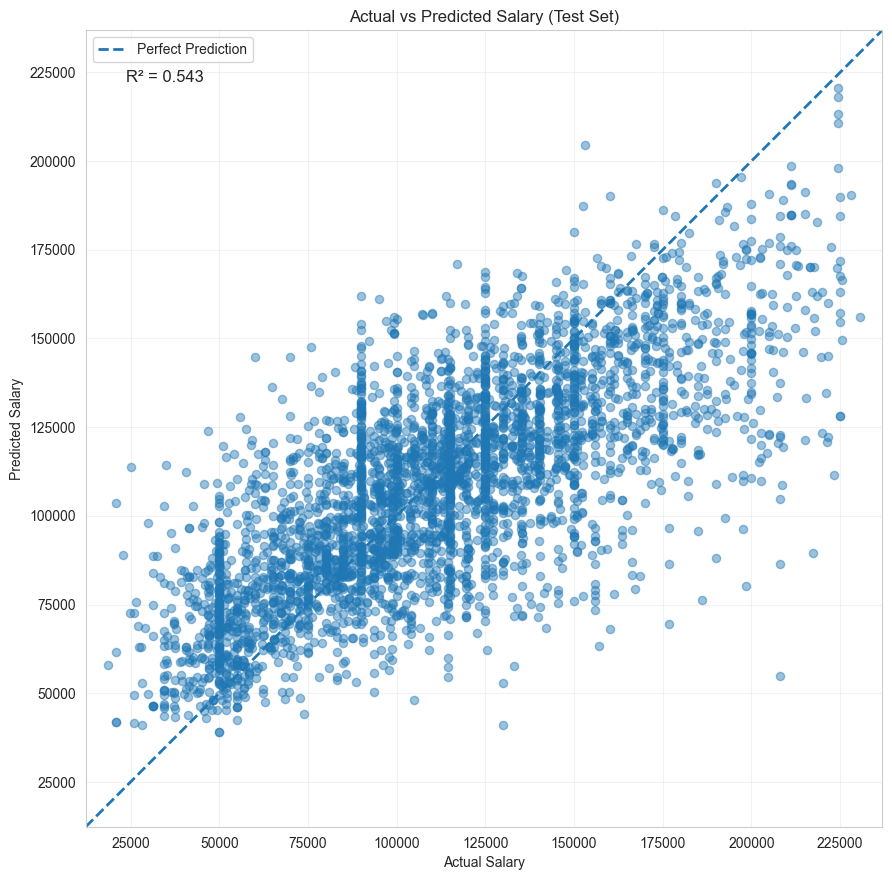

In [44]:
# ============================================================
# ACTUAL vs PREDICTED SCATTER PLOT
# RUN THIS AFTER YOUR TUNING CODE
#
# Uses:
# - test_pred   (predictions on log scale)
# - y_test      (actual log salary)
#
# Converts back to real salary values
# X-axis = Actual
# Y-axis = Predicted
# SAME SCALE on both axes
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

# ------------------------------------------------------------
# Convert from log scale to real salaries
# ------------------------------------------------------------

actual_salary = np.expm1(y_test.values)
pred_salary   = np.expm1(test_pred)

# ------------------------------------------------------------
# Determine common axis range
# ------------------------------------------------------------

min_val = min(actual_salary.min(), pred_salary.min())
max_val = max(actual_salary.max(), pred_salary.max())

# optional padding
pad = (max_val - min_val) * 0.03

axis_min = min_val - pad
axis_max = max_val + pad

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(9,9))

plt.scatter(
    actual_salary,
    pred_salary,
    alpha=0.45,
    s=35
)

# Perfect prediction line
plt.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

# Equal axis scaling
plt.xlim(axis_min, axis_max)
plt.ylim(axis_min, axis_max)
plt.gca().set_aspect('equal', adjustable='box')

# Labels
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary (Test Set)")

# R2 annotation
r2 = r2_score(actual_salary, pred_salary)

plt.text(
    0.05,
    0.95,
    f"R² = {r2:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=12
)

plt.legend()
plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# Prediction Interval in Current XGBoost Salary Prediction

In [45]:
# ============================================================
# 95% PREDICTION INTERVALS
# RUN THIS AFTER TUNING CODE ABOVE
#
# Uses:
# - best_xgb
# - X_val_F
# - X_test_F
# - y_val
# - y_test
# - test_idx
# - df
#
# IMPORTANT:
# Model predicts salary_log
# Convert back using expm1()
# ============================================================

# ============================================================
# STEP 1: VALIDATION PREDICTIONS (CALIBRATION SET)
# ============================================================

val_pred_log = best_xgb.predict(X_val_F)

val_actual = np.expm1(y_val.values)
val_pred   = np.expm1(val_pred_log)

# absolute residuals in real salary space
val_abs_error = np.abs(val_actual - val_pred)

# ============================================================
# STEP 2: CONFORMAL ERROR QUANTILE
# ============================================================

alpha = 0.05   # 95% interval

q_hat = np.quantile(val_abs_error, 1 - alpha)

print("95% Error Quantile:", round(q_hat,2))

# ============================================================
# STEP 3: TEST SET PREDICTIONS
# ============================================================

test_pred_log = best_xgb.predict(X_test_F)

test_actual = np.expm1(y_test.values)
test_pred   = np.expm1(test_pred_log)

# ============================================================
# STEP 4: BUILD INTERVALS
# ============================================================

lower = test_pred - q_hat
upper = test_pred + q_hat

lower = np.maximum(lower, 0)

# ============================================================
# STEP 5: BUILD RESULTS DATAFRAME
# ============================================================

pi_results = df.loc[test_idx].copy()

pi_results["Actual_Salary"] = test_actual
pi_results["Predicted_Salary"] = test_pred
pi_results["PI_Lower_95"] = lower
pi_results["PI_Upper_95"] = upper

# Was true salary inside interval?
pi_results["Covered"] = (
    (pi_results["Actual_Salary"] >= pi_results["PI_Lower_95"]) &
    (pi_results["Actual_Salary"] <= pi_results["PI_Upper_95"])
).astype(int)

pi_results["Interval_Width"] = (
    pi_results["PI_Upper_95"] - pi_results["PI_Lower_95"]
)

# ============================================================
# STEP 6: SUMMARY
# ============================================================

coverage = pi_results["Covered"].mean()
avg_width = pi_results["Interval_Width"].mean()

summary = pd.DataFrame([{
    "Confidence_Level": "95%",
    "Coverage_Rate": coverage,
    "Average_Interval_Width": avg_width,
    "Median_Interval_Width": pi_results["Interval_Width"].median()
}])

display(summary)

# ============================================================
# STEP 7: SAMPLE OUTPUT
# ============================================================

display(
    pi_results[
        [
            "job_title_short",
            "job_country",
            "Actual_Salary",
            "Predicted_Salary",
            "PI_Lower_95",
            "PI_Upper_95",
            "Covered"
        ]
    ].head(20)
)

# ============================================================
# STEP 8: COVERAGE BY JOB TITLE
# ============================================================

coverage_title = (
    pi_results.groupby("job_title_short")["Covered"]
    .mean()
    .sort_values()
)

display(coverage_title)

# ============================================================
# STEP 9: COVERAGE BY COUNTRY
# ============================================================

coverage_country = (
    pi_results.groupby("job_country")["Covered"]
    .mean()
)

display(coverage_country)

95% Error Quantile: 58885.26


,Confidence_Level,Coverage_Rate,Average_Interval_Width,Median_Interval_Width
0,95%,0.954124,117460.480851,117770.515625


,job_title_short,job_country,Actual_Salary,Predicted_Salary,PI_Lower_95,PI_Upper_95,Covered
3837,Data Engineer,United States,117500.000000,112199.546875,53314.289063,171084.804687,1
148752,Data Engineer,United States,146100.000000,125172.171875,66286.914063,184057.429687,1
180540,Data Scientist,United States,175000.000000,162711.265625,103826.007813,221596.523437,1
12136,Software Engineer,United States,110219.203491,113429.390625,54544.132813,172314.648437,1
104371,Data Analyst,United States,85280.000000,88898.500000,30013.242188,147783.757812,1
124305,Senior Data Analyst,United States,95000.000000,108062.687500,49177.429688,166947.945312,1
131863,Data Scientist,United States,109200.000000,81405.539062,22520.281250,140290.796875,1
64825,Data Engineer,United States,90000.000000,103054.617188,44169.359375,161939.875000,1
221029,Data Engineer,United States,94450.000000,91298.687500,32413.429688,150183.945312,1
102001,Data Scientist,United States,170500.000000,150641.187500,91755.929688,209526.445312,1


job_title_short
Machine Learning Engineer    0.760000
Software Engineer            0.880952
Business Analyst             0.916667
Data Scientist               0.945491
Senior Data Scientist        0.948598
Data Engineer                0.954733
Senior Data Analyst          0.961326
Data Analyst                 0.967331
Senior Data Engineer         0.968182
Name: Covered, dtype: float64

job_country
Canada           0.953488
United States    0.954138
Name: Covered, dtype: float64

In [46]:
# ============================================================
# STANDARD MODEL PERFORMANCE METRICS
# ============================================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

perf = pd.DataFrame([{
    "R2": r2_score(test_actual, test_pred),
    "MAE": mean_absolute_error(test_actual, test_pred),
    "RMSE": np.sqrt(mean_squared_error(test_actual, test_pred)),
    "Coverage_95PI": coverage,
    "Avg_PI_Width": avg_width
}])

display(perf)

,R2,MAE,RMSE,Coverage_95PI,Avg_PI_Width
0,0.543048,21792.335864,28617.99445,0.954124,117460.480851


# Explainability (Best Model)

## Individual skills

In [49]:
# Use a SMALL subset (Kernel SHAP is slow)
bg_n = 80
eval_n = 30

X_bg = X_train_F[:bg_n].toarray()
X_eval = X_test_F[:eval_n].toarray()

# Build feature names (same as your pipeline)
structured_names = list(X_struct.columns)
sbert_names = [f"SBERT_{i}" for i in range(emb_train.shape[1])]
tfidf_names = list(tfidf.get_feature_names_out())

feature_names = structured_names + sbert_names + tfidf_names

# SHAP explainer (best model)
explainer = shap.KernelExplainer(best_xgb.predict, X_bg)

shap_values = explainer.shap_values(X_eval, nsamples=200)

100%|██████████| 30/30 [00:16<00:00,  1.80it/s]


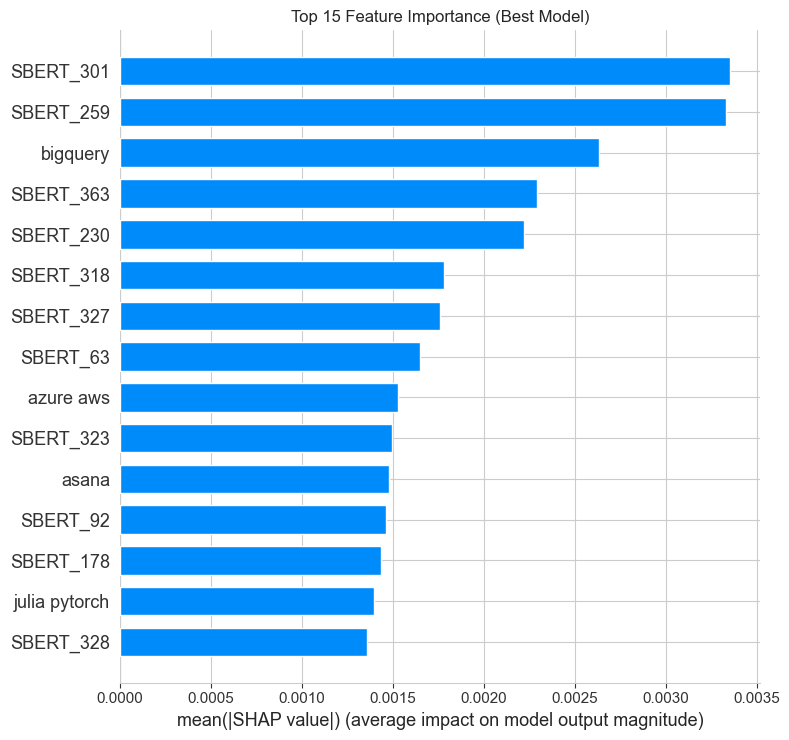

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_eval,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title("Top 15 Feature Importance (Best Model)")
plt.tight_layout()
plt.show()

Right now the plot is dominated by `SBERT` features and `TF-IDF` tokens, which have no contributions in terms of interpretability. The code below will filter the SHAP output to obly show skill-related features:

In [53]:
all_skills = sorted({
    skill
    for skills in df["skills_list"]
    if isinstance(skills, list)
    for skill in skills
})

print("Number of unique skills:", len(all_skills))

Number of unique skills: 214


In [54]:
shap_df = pd.DataFrame(shap_values, columns=feature_names)
X_eval_df = pd.DataFrame(X_eval, columns=feature_names)

skill_cols = [col for col in feature_names if col.lower() in set(all_skills)]

print("Number of matched skill columns:", len(skill_cols))

X_eval_skills = X_eval_df[skill_cols]
shap_skills = shap_df[skill_cols]

Number of matched skill columns: 181


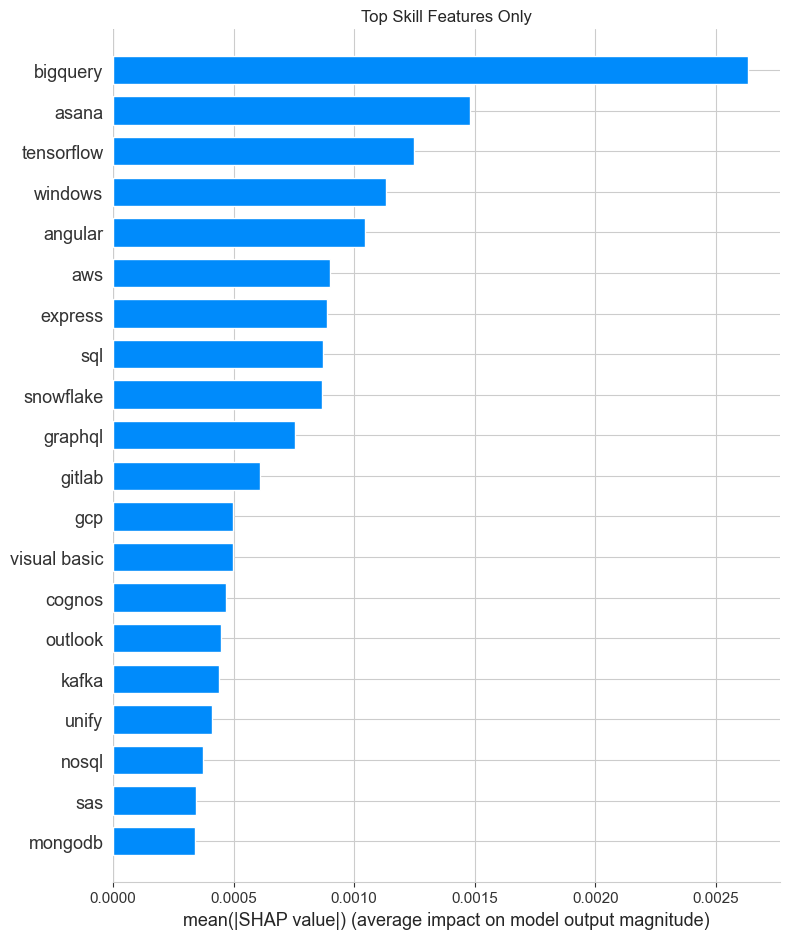

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_skills.values,
    X_eval_skills,
    feature_names=skill_cols,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title("Top Skill Features Only")
plt.tight_layout()
plt.show()

Getting the numerical skill impact

In [72]:
skill_impact_abs = shap_skills.abs().mean()
skill_impact_signed = shap_skills.mean()

skill_impact_df = pd.DataFrame({
    "Skill": skill_impact_abs.index,
    "Importance": skill_impact_abs.values,
    "Direction": skill_impact_signed.values
}).sort_values("Importance", ascending=False)

display(skill_impact_df.head(20))

,Skill,Importance,Direction
14,bigquery,0.002635,0.000113
7,asana,0.001480,0.001480
155,tensorflow,0.001246,-0.001246
175,windows,0.001131,0.001131
3,angular,0.001044,-0.001044
11,aws,0.000898,0.000898
47,express,0.000888,-0.000888
146,sql,0.000869,0.000869
139,snowflake,0.000865,-0.000105
62,graphql,0.000753,0.000753


## EDA

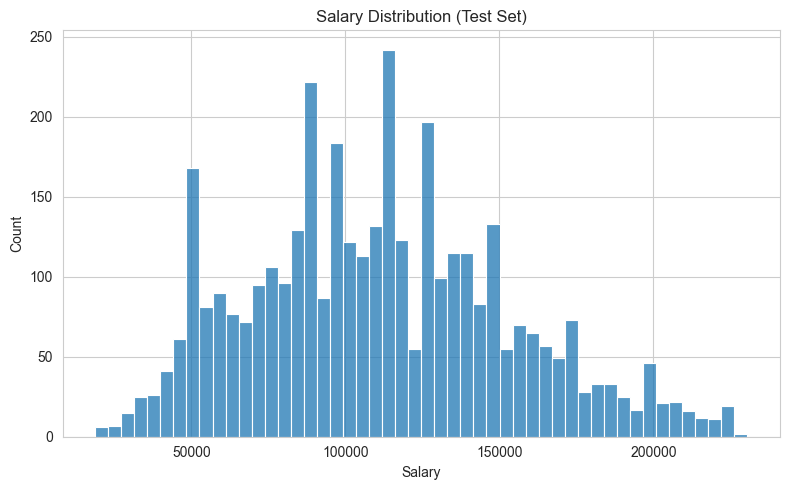

In [80]:
plt.figure(figsize=(8,5))

sns.histplot(np.expm1(y_test.values), bins=50)

plt.title("Salary Distribution (Test Set)")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Just checked the salary distribution again because my plan was that we were going to select the entries for the counterfactuals based off salary brackets so that there's more representation. It describes how the market values skills across different job levels. 

## Counterfactuals

In [87]:
# make sure this exists
X_test_dense = pd.DataFrame(X_test_F.toarray(), columns=feature_names)

# helper: find columns related to a skill
def get_skill_columns(skill):
    return [c for c in feature_names if c.lower() == skill]

def add_skill(row, skill):
    row_new = row.copy()
    cols = get_skill_columns(skill)

    for c in cols:
        if row_new[c] == 0:  # only add if not already present
            row_new[c] = 1

    return row_new

## One Sample (for experimenting purposes only)

This is an illustrative example of a single job profile. Final conclusions are based on aggregated results.

In [88]:
sample_idx = 0
row = X_test_dense.iloc[sample_idx].copy()

base_pred_log = best_xgb.predict(row.values.reshape(1, -1))[0]
base_salary = np.expm1(base_pred_log)

print("Base salary:", base_salary)

Base salary: 74955.11


In [90]:
row_python = add_skill(row, "python")

pred_python = best_xgb.predict(row_python.values.reshape(1, -1))[0]
salary_python = np.expm1(pred_python)

python_gain = salary_python - base_salary

print("Python alone gain:", python_gain)

Python alone gain: 1287.7031


In [91]:
row_sql = add_skill(row, "sql")

pred_sql = best_xgb.predict(row_sql.values.reshape(1, -1))[0]
salary_sql = np.expm1(pred_sql)

sql_gain = salary_sql - base_salary

print("SQL alone gain:", sql_gain)

SQL alone gain: -535.21094


In [92]:
row_both = add_skill(row, "python")
row_both = add_skill(row_both, "sql")

pred_both = best_xgb.predict(row_both.values.reshape(1, -1))[0]
salary_both = np.expm1(pred_both)

both_gain = salary_both - base_salary

print("Python + SQL gain:", both_gain)

Python + SQL gain: 743.3047


In [93]:
expected = python_gain + sql_gain
interaction = both_gain - expected

print("Expected (additive):", expected)
print("Actual:", both_gain)
print("Interaction:", interaction)

Expected (additive): 752.4922
Actual: 743.3047
Interaction: -9.1875


## Aggregated Results (Final)

In [ ]:
test_df = pd.DataFrame({
    "salary": np.expm1(y_test.values)
})

test_df["bin"] = pd.qcut(
    test_df["salary"],
    q=3,
    labels=["low", "mid", "high"]
)

In [95]:
sample_indices = []

for b in ["low", "mid", "high"]:
    idx = test_df[test_df["bin"] == b].sample(7, random_state=42).index
    sample_indices.extend(idx)

In [96]:
results = []

for i in sample_indices:
    row = X_test_dense.iloc[i].copy()

    base = np.expm1(best_xgb.predict(row.values.reshape(1,-1))[0])

    # python
    row_p = add_skill(row, "python")
    p = np.expm1(best_xgb.predict(row_p.values.reshape(1,-1))[0])

    # sql
    row_s = add_skill(row, "sql")
    s = np.expm1(best_xgb.predict(row_s.values.reshape(1,-1))[0])

    # both
    row_ps = add_skill(row, "python")
    row_ps = add_skill(row_ps, "sql")
    ps = np.expm1(best_xgb.predict(row_ps.values.reshape(1,-1))[0])

    python_gain = p - base
    sql_gain = s - base
    both_gain = ps - base

    expected = python_gain + sql_gain
    interaction = both_gain - expected

    results.append({
        "python_gain": python_gain,
        "sql_gain": sql_gain,
        "interaction": interaction
    })

interaction_df = pd.DataFrame(results)

display(interaction_df.describe())

,python_gain,sql_gain,interaction
count,21.000000,21.000000,21.000000
mean,1411.246094,818.180420,137.585190
std,1591.188721,1835.211182,370.448212
min,-1208.789062,-2253.507812,-922.554688
25%,-136.164062,-188.648438,-1.679688
50%,1374.453125,132.632812,35.437500
75%,2993.421875,2239.015625,309.195312
max,3993.835938,4452.640625,976.101562


In [99]:
interaction_df["tier"] = test_df.loc[sample_indices, "bin"].values

display(interaction_df.groupby("tier").mean())

C:\Users\Raymond\AppData\Local\Temp\ipykernel_26464\738332804.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(interaction_df.groupby("tier").mean())


,python_gain,sql_gain,interaction
tier,,,
low,1157.050171,875.231018,126.348770
mid,1524.591553,921.347107,135.297989
high,1552.096558,657.963196,151.108810


In [97]:
summary = pd.DataFrame([{
    "Avg Python Gain": interaction_df["python_gain"].mean(),
    "Avg SQL Gain": interaction_df["sql_gain"].mean(),
    "Avg Interaction": interaction_df["interaction"].mean()
}])

display(summary)

,Avg Python Gain,Avg SQL Gain,Avg Interaction
0,1411.246094,818.18042,137.58519


In [ ]:
avg_python = summary["Avg Python Gain"].values[0]
avg_sql = summary["Avg SQL Gain"].values[0]
avg_interaction = summary["Avg Interaction"].values[0]

print(f"Python increases predicted salary by approx: {avg_python:.2f}")
print(f"SQL increases salary by approx: {avg_sql:.2f}")

if avg_interaction < 0:
    print("There is a negative interaction (diminishing returns).")
else:
    print("There is a positive interaction (synergy).")

Python increases salary by approx: 1411.25
SQL increases salary by approx: 818.18
There is a positive interaction (synergy).


## Counterfactuals